<a href="https://colab.research.google.com/github/Abeldb11/LLM_opt/blob/main/KD_small.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import gc
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from transformers import GPT2LMHeadModel, GPT2Tokenizer
import matplotlib.pyplot as plt
import numpy as np
from datasets import load_dataset

# 1. Clear GPU memory cache
gc.collect()
torch.cuda.empty_cache()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float16 if torch.cuda.is_available() else torch.float32

In [3]:
STUDENT_ID = "gpt2"         # 124M
TEACHER_ID = "gpt2-medium"  # 355M
BATCH_SIZE = 2              # Low per-step VRAM footprint
SEQ_LEN = 128               # Short sequence to avoid attention OOM
GRAD_ACCUM_STEPS = 4        # Effective batch size = 2 * 4 = 8
MAX_TRAIN_STEPS = 50        # Fast demo run (increase as needed)
MAX_EVAL_STEPS = 20

In [6]:
tokenizer = GPT2Tokenizer.from_pretrained(STUDENT_ID)
tokenizer.pad_token = tokenizer.eos_token

raw_dataset = load_dataset("salesforce/wikitext", "wikitext-2-raw-v1")

class TextChunkDataset(Dataset):
    def __init__(self, raw_data, tokenizer, seq_len):
        full_text = "\n\n".join([t for t in raw_data if t.strip()])
        tokens = tokenizer(full_text, return_tensors="pt")["input_ids"].squeeze(0)
        # Split tokens into uniform chunks
        num_chunks = len(tokens) // seq_len
        self.chunks = tokens[:num_chunks * seq_len].view(-1, seq_len)

    def __len__(self):
        return len(self.chunks)

    def __getitem__(self, idx):
        return self.chunks[idx]

train_dataset = TextChunkDataset(raw_dataset["train"]["text"], tokenizer, SEQ_LEN)
val_dataset = TextChunkDataset(raw_dataset["validation"]["text"], tokenizer, SEQ_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# -------------------------------------------------------------
# 3. Model Initialization (Loaded in fp16)
# -------------------------------------------------------------
print("Loading Student (124M)...")
student = GPT2LMHeadModel.from_pretrained(STUDENT_ID, torch_dtype=dtype).to(device)

print("Loading Teacher (355M)...")
teacher = GPT2LMHeadModel.from_pretrained(TEACHER_ID, torch_dtype=dtype).to(device)
teacher.eval()
for p in teacher.parameters():
    p.requires_grad = False  # Completely freeze teacher

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…): reconstructing file:   0%|          |  0.00B /  733kB            

wikitext-2-raw-v1/test-00000-of-00001.pa(…): downloading bytes:           |  0.00B            

wikitext-2-raw-v1/train-00000-of-00001.p(…): reconstructing file:   0%|          |  0.00B / 6.36MB            

wikitext-2-raw-v1/train-00000-of-00001.p(…): downloading bytes:           |  0.00B            

...

config.json:   0%|          | 0.00/718 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.52GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [7]:
def evaluate(model, dataloader, max_steps=MAX_EVAL_STEPS):
    model.eval()
    total_loss = 0.0
    steps = 0
    with torch.no_grad():
        for batch in dataloader:
            if steps >= max_steps:
                break
            inputs = batch.to(device)
            loss = model(inputs, labels=inputs).loss
            total_loss += loss.item()
            steps += 1

    avg_loss = total_loss / steps
    perplexity = float(np.exp(avg_loss))
    return {"loss": avg_loss, "perplexity": perplexity}

# Baseline Evaluation
print("\n--- Evaluating Baseline GPT-2 ---")
metrics_before = evaluate(student, val_loader)
print(f"Before KD -> Loss: {metrics_before['loss']:.4f} | Perplexity: {metrics_before['perplexity']:.2f}")


--- Evaluating Baseline GPT-2 ---


[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Before KD -> Loss: 4.0345 | Perplexity: 56.51


In [8]:
optimizer = torch.optim.AdamW(student.parameters(), lr=5e-5)
temperature = 2.0
alpha = 0.5

student.train()
optimizer.zero_grad()

print("\n--- Starting Knowledge Distillation ---")
step = 0
for batch in train_loader:
    if step >= MAX_TRAIN_STEPS:
        break

    inputs = batch.to(device)

    # 1. Student Forward Pass
    student_outputs = student(inputs, labels=inputs)
    hard_loss = student_outputs.loss
    student_logits = student_outputs.logits

    # 2. Teacher Forward Pass (No gradients, half precision)
    with torch.no_grad():
        teacher_logits = teacher(inputs).logits

    # 3. Distillation Loss (KL Divergence on softened logits)
    soft_targets = F.softmax(teacher_logits / temperature, dim=-1)
    soft_prob = F.log_softmax(student_logits / temperature, dim=-1)
    kd_loss = F.kl_div(soft_prob, soft_targets, reduction="batchmean") * (temperature ** 2)

    total_loss = (alpha * hard_loss + (1.0 - alpha) * kd_loss) / GRAD_ACCUM_STEPS
    total_loss.backward()

    # Step optimizer only after accumulating gradients
    if (step + 1) % GRAD_ACCUM_STEPS == 0:
        optimizer.step()
        optimizer.zero_grad()

    step += 1
    if step % 10 == 0:
        print(f"Step {step}/{MAX_TRAIN_STEPS} | Batch Loss: {total_loss.item() * GRAD_ACCUM_STEPS:.4f}")

# Clean intermediate memory
del teacher
gc.collect()
torch.cuda.empty_cache()

# -------------------------------------------------------------
# 6. Evaluation After Distillation
# -------------------------------------------------------------
print("\n--- Evaluating Optimized GPT-2 ---")
metrics_after = evaluate(student, val_loader)
print(f"After KD  -> Loss: {metrics_after['loss']:.4f} | Perplexity: {metrics_after['perplexity']:.2f}")


--- Starting Knowledge Distillation ---
Step 10/50 | Batch Loss: 80.7391
Step 20/50 | Batch Loss: 74.2421
Step 30/50 | Batch Loss: 66.8065
Step 40/50 | Batch Loss: 83.4809
Step 50/50 | Batch Loss: 65.0000

--- Evaluating Optimized GPT-2 ---
After KD  -> Loss: 4.0183 | Perplexity: 55.61


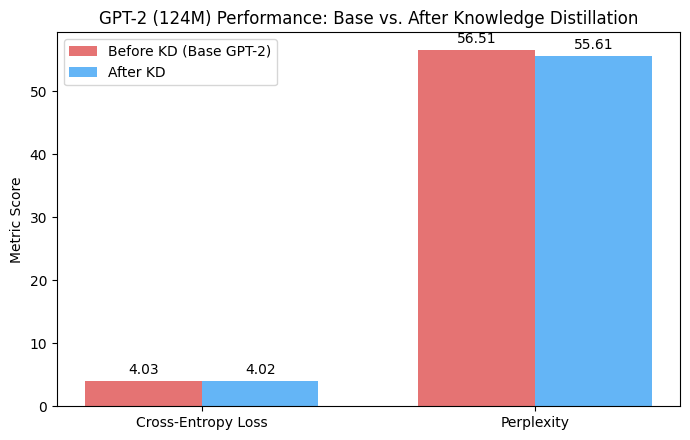

In [9]:
#7. Visualization
# -------------------------------------------------------------
def visualize_results(before, after):
    labels = ["Cross-Entropy Loss", "Perplexity"]
    before_vals = [before["loss"], before["perplexity"]]
    after_vals = [after["loss"], after["perplexity"]]

    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(7, 4.5))
    rects1 = ax.bar(x - width/2, before_vals, width, label="Before KD (Base GPT-2)", color="#e57373")
    rects2 = ax.bar(x + width/2, after_vals, width, label="After KD", color="#64b5f6")

    ax.set_ylabel("Metric Score")
    ax.set_title("GPT-2 (124M) Performance: Base vs. After Knowledge Distillation")
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.legend()

    ax.bar_label(rects1, padding=3, fmt="%.2f")
    ax.bar_label(rects2, padding=3, fmt="%.2f")

    plt.tight_layout()
    plt.show()

visualize_results(metrics_before, metrics_after)